IMPORT PACZEK

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import slab
import pickle
from glob import glob
from mtrf.model import TRF
import os

PARAMETRY GLOBALNE

In [67]:
subjects = [f"pilot_{i}" for i in range(7, 10)]

new_fs = 64
tmin, tmax = 0, 0.35
regularization = [0.1, 1, 10, 100]

STIMULUS

In [68]:
def build_stimulus(wav_files, idyom_df, log_df):
    mvar_stimulus = []
    for wf in wav_files:
        fname = os.path.basename(wf)

        sound = slab.Sound(wf).channel(0).resample(int(44100 / 3))

        env = sound.envelope().resample(new_fs).data.reshape(-1, 1)
        onsets = np.diff(env, axis=0, prepend=0)
        onsets[onsets < 0] = 0

        n_samples = len(env)

        m_feats = np.zeros((n_samples, 4))

        # IDYOM
        if isinstance(idyom_df, pd.DataFrame):
            col = 'filename' if 'filename' in idyom_df.columns else idyom_df.columns[0]
            track = idyom_df[idyom_df[col] == fname]
            for _, row in track.iterrows():
                idx = int(row['onset_sec'] * new_fs)
                if idx < n_samples:
                    m_feats[idx, :] = [row['Hp'], row['Ho'], row['Sp'], row['So']]

        # harmonicity
        trial = log_df[log_df['filename'] == fname]
        is_harm = 0
        if not trial.empty:
            is_harm = 1 if trial['harmonicity'].iloc[0] == 'harm' else 0
        harm = np.full((n_samples, 1), is_harm)

        stim = np.concatenate([env, onsets, m_feats, harm], axis=1)
        mvar_stimulus.append(stim)

    return mvar_stimulus

def safe_zscore(x):
    x = np.array(x)
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    std[std == 0] = 1
    return (x - mean) / std

GLOBALNA ANALIZA

In [69]:
results_A = []
results_AM = []
results_AMH = []
models_AMH = []

for subject in subjects:

    print(f"\nProcessing {subject}")

    try:
        # PATHS
        fif_path = f"/Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/epochs/{subject}_epo.fif"
        log_path = f"/Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/logs/{subject}_logs.csv"
        idyom_path = "/Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/idyom_vectors.pickle"
        wav_path = "/Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/soundpool/*harm*.wav"

        # LOAD DATA
        log_df = pd.read_csv(log_path)
        epochs = mne.read_epochs(fif_path, preload=True).pick_types(eeg=True)

        response = [e.T for e in epochs.get_data()]  # (time, channels)

        idyom_df = pickle.load(open(idyom_path, "rb"))

        wav_dict = {os.path.basename(f): f for f in glob(wav_path)}

        # LOG = ORDER
        ordered_fnames = log_df["filename"].values #czy na pewno???

        ordered_wavs = [wav_dict[f] for f in ordered_fnames if f in wav_dict]

        # STIMULUS
        stim_all = build_stimulus(ordered_wavs, idyom_df, log_df)

        # ALIGNMENT CHECK
        print("stim:", len(stim_all))
        print("resp:", len(response))

        n = min(len(stim_all), len(response))

        stim = stim_all[:n]
        resp = response[:n]

        # SAFE ZSCORE + CHECK
        for i in range(n):
            stim[i] = safe_zscore(stim[i])
            resp[i] = safe_zscore(resp[i])

            if np.isnan(stim[i]).any() or np.isnan(resp[i]).any():
                raise ValueError(f"NaN detected in trial {i}")


        # TRF MODELS

        # A
        trf_A = TRF()
        trf_A.train([s[:, :2] for s in stim], resp, new_fs, tmin, tmax, regularization, k=3)
        _, r_A = trf_A.predict([s[:, :2] for s in stim], resp)

        # AM
        trf_AM = TRF()
        trf_AM.train([s[:, :6] for s in stim], resp, new_fs, tmin, tmax, regularization, k=3)
        _, r_AM = trf_AM.predict([s[:, :6] for s in stim], resp)

        # AMH
        trf_AMH = TRF()
        trf_AMH.train(stim, resp, new_fs, tmin, tmax, regularization, k=3)
        _, r_AMH = trf_AMH.predict(stim, resp)

        # RESULTS
        results_A.append(np.nanmean(r_A))
        results_AM.append(np.nanmean(r_AM))
        results_AMH.append(np.nanmean(r_AMH))

        models_AMH.append(trf_AMH)

        print("OK:", subject)

    except Exception as e:
        print("ERROR:", subject, e)
        continue

print("\nDONE")


Processing pilot_7
Reading /Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/epochs/pilot_7_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...  100000.00 ms
        0 CTF compensation matrices available
Not setting metadata
18 matching events found
No baseline correction applied
0 projection items activated
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
stim: 15
resp: 18
ERROR: pilot_7 stimulus and response trials must have the same length!

Processing pilot_8
Reading /Users/kornelia/PycharmProjects/inharmonic_melodies/TRF_analysis/data/epochs/pilot_8_epo.fif ...
    Found the data of interest:
        t =    -199.22 ...  100000.00 ms
        0 CTF compensation matrices available
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
stim: 15
resp: 30
ERROR: pilot_8 stimulus and response tr

WYNIKI MODELI

In [59]:
results_A = np.array(results_A)
results_AM = np.array(results_AM)
results_AMH = np.array(results_AMH)
print("A raw:", results_A)
print("A length:", len(results_A))
print("A:", results_A.mean())
print("AM:", results_AM.mean())
print("AMH:", results_AMH.mean())

A raw: []
A length: 0
A: nan
AM: nan
AMH: nan


/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3325428378.py:6: RuntimeWarning: Mean of empty slice.
  print("A:", results_A.mean())
/Users/kornelia/PycharmProjects/inharmonic_melodies/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3325428378.py:7: RuntimeWarning: Mean of empty slice.
  print("AM:", results_AM.mean())
/var/folders/ss/rgp4bsh97c12ptvklx4syyd00000gr/T/ipykernel_18041/3325428378.py:8: RuntimeWarning: Mean of empty slice.
  print("AMH:", results_AMH.mean())


FIGURE 1 - Music score of a segment of auditory stimulus, with its corresponding features = DO POPRAWY!!!

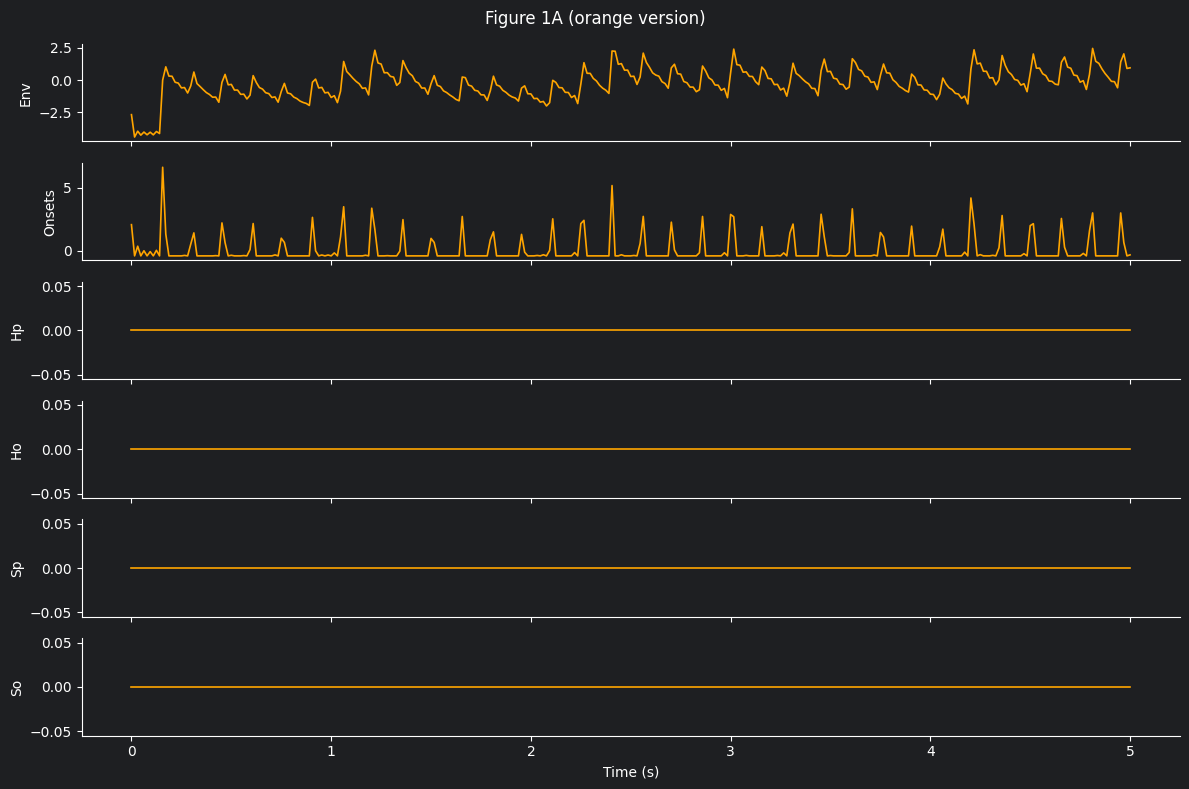

In [41]:
def plot_figure_1a(mvar_stimulus_epoch, fs, start_sec=0, end_sec=5):
    mvar_stimulus_epoch = np.array(mvar_stimulus_epoch)
    data = mvar_stimulus_epoch[:, :6]  # bez harm
    features = ['Env', 'Onsets', 'Hp', 'Ho', 'Sp', 'So']
    t = np.arange(data.shape[0]) / fs
    mask = (t >= start_sec) & (t <= end_sec)
    t_crop = t[mask]
    d_crop = data[mask, :]
    fig, axes = plt.subplots(6, 1, figsize=(12, 8), sharex=True)

    for i in range(6):
        axes[i].plot(t_crop, d_crop[:, i], color='orange', linewidth=1.2)
        axes[i].set_ylabel(features[i])
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    axes[-1].set_xlabel("Time (s)")
    plt.suptitle("Figure 1A (orange version)")
    plt.tight_layout()
    plt.show()
plot_figure_1a(mvar_stimulus[0], new_fs)

FIGURE 2 - WYKRES PORÓWNUJĄCY MODELA ZE WSZYSTKICH GŁÓW

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

results_A = np.array(results_A)
results_AM = np.array(results_AM)
results_AMH = np.array(results_AMH)

print("N subjects:", len(results_A))

print("A mean:", results_A.mean())
print("AM mean:", results_AM.mean())
print("AMH mean:", results_AMH.mean())

plt.figure(figsize=(12,5))

labels = [f"P{i}" for i in range(1, len(results_A)+1)]

plt.plot(labels, results_A, marker='o', label='A')
plt.plot(labels, results_AM, marker='o', label='AM')
plt.plot(labels, results_AMH, marker='o', label='AMH')

plt.ylabel("Prediction r")
plt.title("TRF results across subjects")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FIGURE 3 - Ridge regression weights for TRF = DO POPRAWY!!!

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 2) + inhomogeneous part.

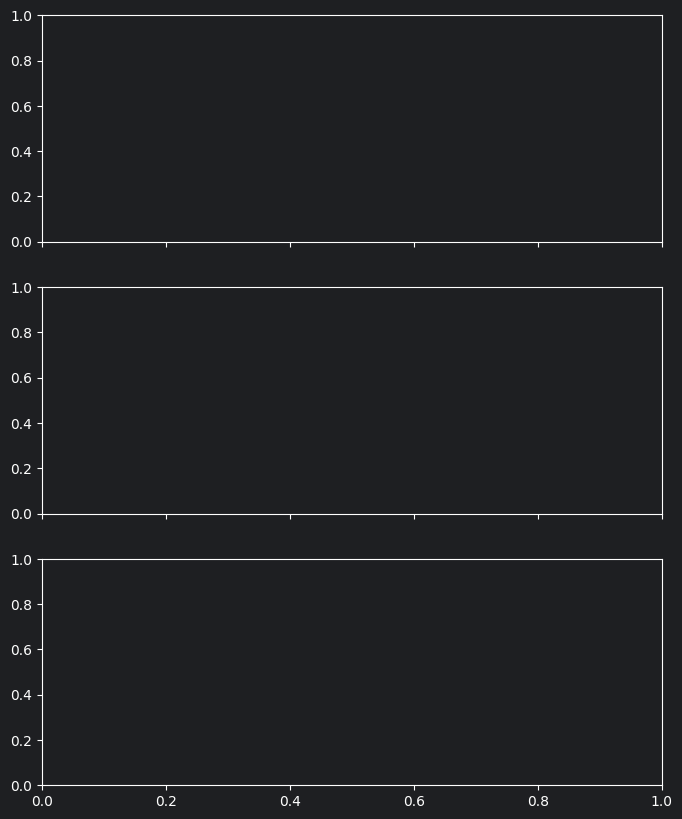

In [70]:
def plot_figure_2e(trf_model, channels_idx=[4, 5], ch_names=['Fz', 'Cz', 'Pz']):
    weights = trf_model.weights
    n_features, n_lags, n_channels = weights.shape

    # Etykiety cech zgodnie z kolejnością w Figure 2E
    # Kolejność w artykule od góry: Env, Env', Sp, Hp, So, Ho
    # Dostosowujemy do Twojego modelu AMH (7 cech) - wywalić harm
    features_labels = ['Env', "Env'", 'Sp', 'Hp', 'So', 'Ho']
    features_labels = features_labels[:n_features]

    # tmin i tmax powinny być zgodne z parametrami treningu (np. 0, 0.35)
    lags_ms = np.linspace(tmin * 1000, tmax * 1000, n_lags)

    fig, axes = plt.subplots(len(channels_idx), 1, figsize=(8, 10), sharex=True)

    if len(channels_idx) == 1:
        axes = [axes]

    for i, ch_idx in enumerate(channels_idx):
        if ch_idx >= n_channels:
            continue

        # Wyciągnięcie wag dla danego kanału
        w = weights[:, :, ch_idx]

        # Normalizacja wag dla każdego kanału oddzielnie
        w_norm = w / (np.max(np.abs(w)) + 1e-8)

        im = axes[i].imshow(
            w_norm,
            aspect='auto',
            origin='upper', # Env na górze wykresu
            cmap='RdBu_r',  # Red-Blue reversed: czerwony(+) / niebieski(-) [2, 3]
            extent=[lags_ms, lags_ms[-1], n_features - 0.5, -0.5],
            vmin=-1,
            vmax=1)

        axes[i].set_yticks(np.arange(n_features))
        axes[i].set_yticklabels(features_labels)

        axes[i].set_ylabel(ch_names[i] if i < len(ch_names) else f"Ch {ch_idx}",
                           fontsize=12, fontweight='bold', rotation=0, labelpad=25)

        axes[i].axvline(0, color='black', linewidth=0.8, linestyle='--')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Normalised TRF weights")

    plt.xlabel("Latency (ms)")
    fig.suptitle(f"Figure 2E: TRF Weights - Subject: {subject}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])
    plt.show()

    plt.tight_layout()
    plt.show()

plot_figure_2e(trf_amh, channels_idx=[0, 1, 2])